In [ ]:
#Bibliotecas Utilizadas
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import json
import copy
import matplotlib.pyplot as plt
import numpy as np

In [3]:
caminho_ml_model = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\src\ml_model"
if caminho_ml_model not in sys.path:
    sys.path.insert(0, caminho_ml_model)

for modulo_conflitante in ['model', 'dataset', 'train']:
    if modulo_conflitante in sys.modules:
        del sys.modules[modulo_conflitante]

from model import RedeSoldagem
from dataset import criar_dataloaders
from train import calcular_metricas, imprimir_metricas

# CÓDIGO DE TREINAMENTO E AUDITORIA
caminho_json = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\modelo\production\melhor_trial.json"

with open(caminho_json, "r") as f:
    melhor_trial = json.load(f)
params = melhor_trial["params"]

caminho_pt = r"C:\Users\Workstation\Documents\GitHub\welding-optuna-pytorch\data\processed\dados_modelo_soldagem.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loader_treino, loader_val = criar_dataloaders(caminho_pt, batch_size=params["batch_size"])
(x_num, _, _), _ = next(iter(loader_treino))
num_features = x_num.shape[1]

dados = torch.load(caminho_pt, weights_only=True)
vocab_size = int(max(dados["X_train_emb_base"].max(), dados["X_train_emb_add"].max()).item() + 1)

modelo = RedeSoldagem(
    num_features_continuas=num_features,
    vocab_size=vocab_size,
    emb_dim=params["emb_dim"],
    hidden_size=params["hidden_size"],
    num_layers=params["num_layers"],
    dropout_rate=params["dropout_rate"],
).to(device)

optimizer = optim.AdamW(modelo.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
criterion = nn.MSELoss()

epochs = 100
best_mse = float('inf')
best_model_weights = None

for epoch in range(1, epochs + 1):
    modelo.train()
    for (xb_num, xb_base, xb_add), yb in loader_treino:
        xb_num, xb_base, xb_add, yb = xb_num.to(device), xb_base.to(device), xb_add.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = modelo(xb_num, xb_base, xb_add)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        
    modelo.eval()
    val_loss = 0
    with torch.no_grad():
        for (xb_num, xb_base, xb_add), yb in loader_val:
            xb_num, xb_base, xb_add, yb = xb_num.to(device), xb_base.to(device), xb_add.to(device), yb.to(device)
            val_loss += criterion(modelo(xb_num, xb_base, xb_add), yb).item()
    
    if val_loss < best_mse:
        best_mse = val_loss
        best_model_weights = copy.deepcopy(modelo.state_dict())

modelo.load_state_dict(best_model_weights)
modelo.eval()

# TESTE DE PERMUTAÇÃO (SEM VAZAMENTO DE DADOS)
preds_normal, preds_base_shuf, preds_add_shuf, targets = [], [], [], []

with torch.no_grad():
    for (xb_num, xb_base, xb_add), yb in loader_val:
        xb_num, xb_base, xb_add, yb = xb_num.to(device), xb_base.to(device), xb_add.to(device), yb.to(device)
        
        preds_normal.append(modelo(xb_num, xb_base, xb_add))
        
        idx_base = torch.randperm(xb_base.size(0))
        preds_base_shuf.append(modelo(xb_num, xb_base[idx_base], xb_add))
        
        idx_add = torch.randperm(xb_add.size(0))
        preds_add_shuf.append(modelo(xb_num, xb_base, xb_add[idx_add]))
        
        targets.append(yb)

preds_normal = torch.cat(preds_normal)
preds_base_shuf = torch.cat(preds_base_shuf)
preds_add_shuf = torch.cat(preds_add_shuf)
targets = torch.cat(targets)
metricas_normal = calcular_metricas(preds_normal, targets)
metricas_base = calcular_metricas(preds_base_shuf, targets)
metricas_add = calcular_metricas(preds_add_shuf, targets)

print("\n---> IMPACTO: BASELINE (NORMAL)")
imprimir_metricas(metricas_normal, prefixo="  ")
print("\n---> IMPACTO: MATERIAL DE BASE EMBARALHADO")
imprimir_metricas(metricas_base, prefixo="  ")
print("\n---> IMPACTO: MATERIAL DE ADIÇÃO EMBARALHADO")
imprimir_metricas(metricas_add, prefixo="  ")


---> IMPACTO: BASELINE (NORMAL)

  ──────────────────────────────────────────────────────
                             MSE       MAE       R²
  ──────────────────────────────────────────────────────
    voltagem              0.0931    0.2091   0.9071
    amperagem             0.1807    0.3023   0.7807
    velocidade            0.1767    0.2847   0.7501
  ──────────────────────────────────────────────────────
    GERAL                 0.1502    0.2654   0.8126
  ──────────────────────────────────────────────────────


---> IMPACTO: MATERIAL DE BASE EMBARALHADO

  ──────────────────────────────────────────────────────
                             MSE       MAE       R²
  ──────────────────────────────────────────────────────
    voltagem              0.0964    0.2303   0.9038
    amperagem             0.2097    0.3471   0.7455
    velocidade            0.2101    0.3212   0.7030
  ──────────────────────────────────────────────────────
    GERAL                 0.1721    0.2996   0.7841
 

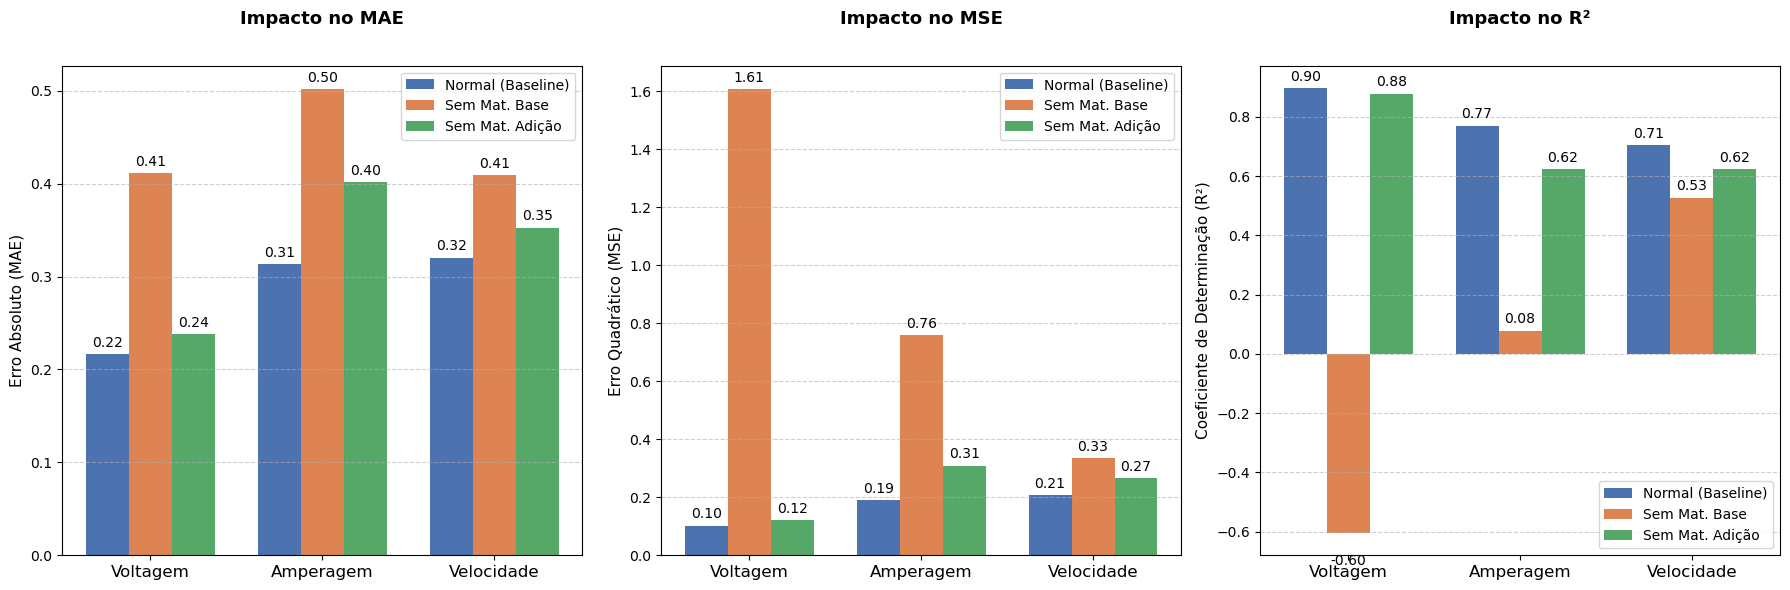

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Rótulos das variáveis
labels = ['Voltagem', 'Amperagem', 'Velocidade']

mae_baseline = [0.2162, 0.3132, 0.3205]
mae_base = [0.4118, 0.5020, 0.4094]
mae_add = [0.2379, 0.4018, 0.3528]

mse_baseline = [0.1023, 0.1888, 0.2086]
mse_base = [1.6072, 0.7590, 0.3343]
mse_add = [0.1213, 0.3092, 0.2657]

r2_baseline = [0.8979, 0.7708, 0.7051]
r2_base = [-0.6049, 0.0787, 0.5273]
r2_add = [0.8788, 0.6247, 0.6244]

x = np.arange(len(labels))
width = 0.25  

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

def plotar_barras(ax, dados_normal, dados_base, dados_add, titulo, ylabel):
    barra1 = ax.bar(x - width, dados_normal, width, label='Normal (Baseline)', color='#4C72B0')
    barra2 = ax.bar(x, dados_base, width, label='Sem Mat. Base', color='#DD8452')
    barra3 = ax.bar(x + width, dados_add, width, label='Sem Mat. Adição', color='#55A868')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    for barras in [barra1, barra2, barra3]:
        for barra in barras:
            altura = barra.get_height()
            deslocamento_y = 3 if altura >= 0 else -15
            alinhamento = 'bottom' if altura >= 0 else 'top'
            
            ax.annotate(f'{altura:.2f}',
                        xy=(barra.get_x() + barra.get_width() / 2, altura),
                        xytext=(0, deslocamento_y),
                        textcoords="offset points",
                        ha='center', va=alinhamento, fontsize=10)

plotar_barras(ax1, mae_baseline, mae_base, mae_add, 'Impacto no MAE\n', 'Erro Absoluto (MAE)')
plotar_barras(ax2, mse_baseline, mse_base, mse_add, 'Impacto no MSE\n', 'Erro Quadrático (MSE)')
plotar_barras(ax3, r2_baseline, r2_base, r2_add, 'Impacto no R²\n', 'Coeficiente de Determinação (R²)')
plt.tight_layout()
plt.show()